In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [190]:
df = pd.read_csv(r"C:/Users/dindu/OneDrive/Desktop/Realty AI/dataset/real_estate_dataset.csv")
print("Shape of dataset:", df.shape)

Shape of dataset: (287, 9)


In [191]:
df.head()

,url,beds,city,date,size,type,baths,price,neighborhood
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,799-1258 sqft,Residential land / Plot,0,2317000.0,Jigani
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,1525-2150 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,658-1003 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,1179-1449 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere


In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           287 non-null    object 
 1   beds          287 non-null    int64  
 2   city          287 non-null    object 
 3   date          287 non-null    object 
 4   size          287 non-null    object 
 5   type          287 non-null    object 
 6   baths         287 non-null    int64  
 7   price         287 non-null    float64
 8   neighborhood  287 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 20.3+ KB


In [193]:
df.describe()

,beds,baths,price
count,287.000000,287.000000,2.870000e+02
mean,2.156794,1.526132,1.956434e+07
std,1.767959,1.771525,4.461799e+07
min,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,4.738000e+06
50%,2.000000,1.000000,1.000000e+07
75%,3.000000,2.000000,2.085000e+07
max,12.000000,12.000000,6.000000e+08


In [194]:
df.columns

Index(['url', 'beds', 'city', 'date', 'size', 'type', 'baths', 'price',
       'neighborhood'],
      dtype='object')

In [195]:
df.isnull().sum()

url             0
beds            0
city            0
date            0
size            0
type            0
baths           0
price           0
neighborhood    0
dtype: int64

In [196]:
df.duplicated().sum()

0

In [197]:
df = df.drop_duplicates()

In [198]:
df.columns = df.columns.str.strip().str.lower()

In [199]:
df = df.drop(columns=['url'])

In [200]:
print(df['size'].head(10))
print(df['price'].head(10))

0     799-1258 sqft
1         1085 sqft
2    1525-2150 sqft
3     658-1003 sqft
4    1179-1449 sqft
5    1199-2484 sqft
6     794-1923 sqft
7            0 sqft
8    1006-1636 sqft
9    1335-2700 sqft
Name: size, dtype: object
0     2317000.0
1    12500000.0
2    23200000.0
3      889000.0
4     6483000.0
5    15000000.0
6     7518000.0
7    39800000.0
8    11100000.0
9    15700000.0
Name: price, dtype: float64


In [201]:
print(df['date'].head())
print(df['date'].dtype)

0    2025-02-19
1    2025-02-19
2    2025-02-19
3    2025-02-19
4    2025-02-19
Name: date, dtype: object
object


In [202]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [203]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [204]:
df = df.drop(columns=['date'])

In [205]:
# Step 1: Remove 'sqft'
df['size'] = df['size'].str.replace('sqft', '', regex=False).str.strip()

# Step 2: Replace 'Varies' with NaN
df['size'] = df['size'].replace('Varies', np.nan)

# Step 3: Split range
size_split = df['size'].str.split('-', expand=True)

# Step 4: Convert safely to numeric
size_split = size_split.apply(pd.to_numeric, errors='coerce')

# Step 5: Take average of range
df['size'] = size_split.mean(axis=1)

In [206]:
df['size'].head()
df['size'].dtype
df['size'].isnull().sum()

54

In [207]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['size'] = pd.to_numeric(df['size'], errors='coerce')

In [208]:
df['size'].head(10)

0    1028.5
1    1085.0
2    1837.5
3     830.5
4    1314.0
5    1841.5
6    1358.5
7       0.0
8    1321.0
9    2017.5
Name: size, dtype: float64

In [209]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = ['city', 'type', 'neighborhood']

In [210]:
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [211]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [212]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]

In [213]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

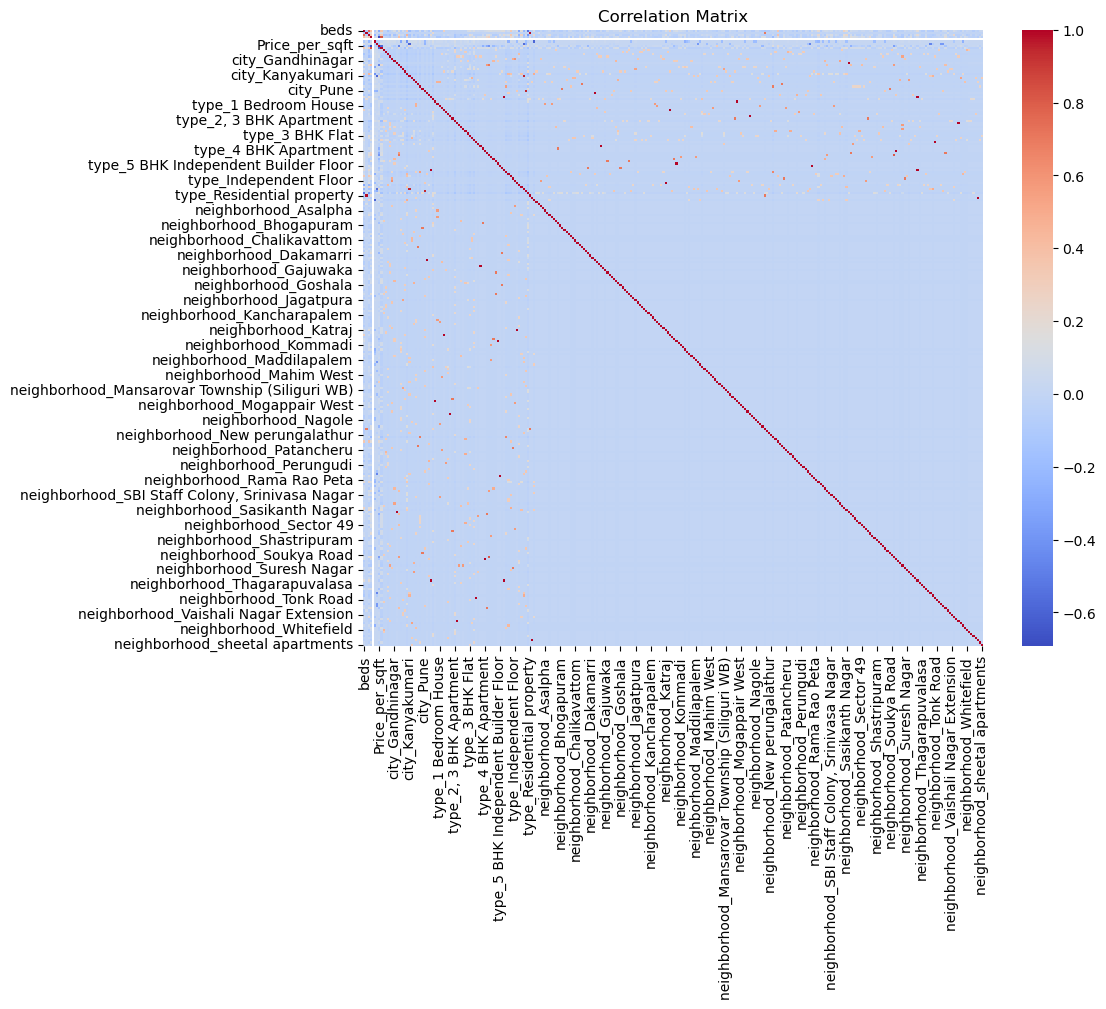

In [222]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

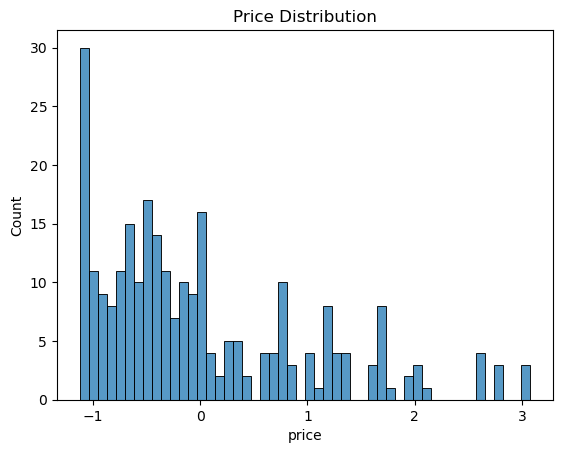

In [215]:
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

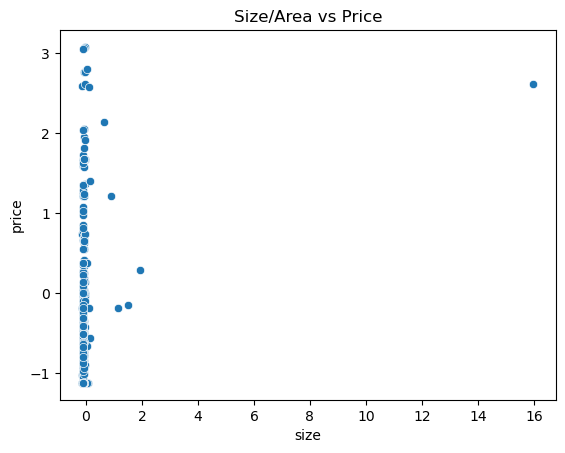

In [216]:
sns.scatterplot(x='size', y='price', data=df)
plt.title("Size/Area vs Price")
plt.show()

In [217]:
print(df.columns)

Index(['beds', 'city', 'size', 'type', 'baths', 'price', 'neighborhood',
       'year', 'month', 'day'],
      dtype='object')


In [218]:
df['Price_per_sqft'] = df['price'] / df['size']

In [219]:
df['Is_Luxury'] = df['price'] > df['price'].mean()
df['Is_Luxury'] = df['Is_Luxury'].astype(int)

In [220]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [226]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [227]:
print("Final Shape:", df.shape)
df.head()

Final Shape: (266, 288)


,beds,size,baths,price,year,month,day,Price_per_sqft,Is_Luxury,city_Bangalore,...,neighborhood_Vidyut Nagar,neighborhood_Wadala,neighborhood_Whitefield,neighborhood_Yelahanka,neighborhood_Yendada,neighborhood_balacheruvu road,neighborhood_good earth hamlet,neighborhood_nallasopara,neighborhood_sector 121,neighborhood_sheetal apartments
0,-1.236673,-0.108486,-0.884493,-0.906571,0.0,0.336111,0.192384,0.576191,0,True,...,False,False,False,False,False,False,False,False,False,False
1,-0.080416,-0.107257,0.283126,0.044057,0.0,0.336111,0.192384,0.026524,1,True,...,False,False,False,False,False,False,False,False,False,False
2,0.497712,-0.090888,-0.884493,1.042950,0.0,0.336111,0.192384,-0.667150,1,True,...,False,False,True,False,False,False,False,False,False,False
3,-0.080416,-0.112793,-0.884493,-1.039881,0.0,0.336111,0.192384,0.630285,0,True,...,False,False,False,False,False,False,False,False,False,False
4,-0.080416,-0.102276,-0.884493,-0.517656,0.0,0.336111,0.192384,0.369599,0,True,...,False,False,False,False,False,False,False,False,False,False
